In [4]:
%load_ext autoreload
%autoreload 2
import numpy as np
import sys
sys.path.append('..')

from src.experiment import QuadraticFormLipschitzVSEtaExperiment, ExperimentHandler, CsvSaver, RastriginLipschitzVSEtaExperiment
from src.problems import generate_random_hessian 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# $\eta_0$ vs Lipshitz constant (quadtratic fucntions)

In [2]:
csv_saver = CsvSaver(path="eta_convergence_results.csv")

eta_multipliers = [0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 100.0]
num_functions_per_eta = 10
num_starts_per_func = 5
n_dim = 2
eps = 0.1
alpha = 0.05

time_complecity = np.power(eps, -2) * np.power(np.log(1/eps),2)

print("Im gonna need on average: ", time_complecity, " iters per one run.")

fixed_hessians = [
    generate_random_hessian(n_dim, min_eig=0.5, max_eig=5.0) 
    for _ in range(num_functions_per_eta)
]
experiments_generator = (
    QuadraticFormLipschitzVSEtaExperiment(
        results_saver=csv_saver,
        n_dim=n_dim,
        eta_multiplier=multiplier,
        H=H_matrix,  
        max_iter=100_000, 
        num_starts=num_starts_per_func,
        eps = eps,
        alpha=alpha
    )
    for multiplier in eta_multipliers
    for H_matrix in fixed_hessians
)

handler = ExperimentHandler(experiments=experiments_generator)
handler.run_all()

Im gonna need on average:  530.1898110478398  iters per one run.
--- Starting experiment queue ---


Progress: 70it [08:05,  6.94s/it]

--- All experiments completed ---


<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/var/folders/gp/n7ttdtg56pg0s6ydv9zj9wth0000gn/T/ipykernel_26468/3509397125.py:22: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Learning Rate Multiplier ($\\eta_0 = \mathrm{multiplier} \cdot \\frac{1}{L}$)", fontsize=12)


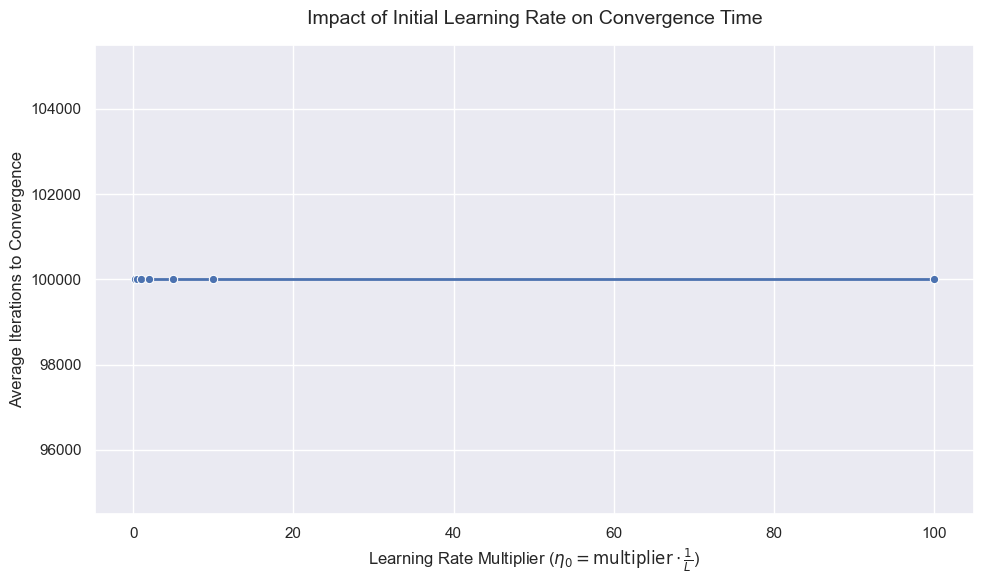

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("eta_convergence_results.csv")

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=df, 
    x="eta_multiplier", 
    y="avg_iters", 
    marker="o", 
    errorbar='sd', 
    linewidth=2
)

#ax.set_xscale("log")

plt.title("Impact of Initial Learning Rate on Convergence Time", fontsize=14, pad=15)
plt.xlabel("Learning Rate Multiplier ($\\eta_0 = \mathrm{multiplier} \cdot \\frac{1}{L}$)", fontsize=12)
plt.ylabel("Average Iterations to Convergence", fontsize=12)

plt.tight_layout()
plt.show()

# $\eta_0$ vs Rastrigin

In [5]:
csv_saver = CsvSaver(path="eta_convergence_rastrigin_results.csv")

eta_multipliers = [0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 100.0]
num_functions_per_eta = 10
num_starts_per_func = 5
n_dim = 2
eps = 0.1
alpha = 0.05
A_param = 10.0

time_complecity = np.power(eps, -2) * np.power(np.log(1/eps),2)
print("Im gonna need on average: ", time_complecity, " iters per one run.")

experiments_generator = (
    RastriginLipschitzVSEtaExperiment(
        results_saver=csv_saver,
        n_dim=n_dim,
        eta_multiplier=multiplier,
        max_iter=100_000, 
        A=A_param,
        num_starts=num_starts_per_func,
        eps=eps,
        alpha=alpha
    )
    for multiplier in eta_multipliers
    for _ in range(num_functions_per_eta)
)

handler = ExperimentHandler(experiments=experiments_generator)
handler.run_all()

Im gonna need on average:  530.1898110478398  iters per one run.
--- Starting experiment queue ---


Progress: 70it [10:45,  9.23s/it]

--- All experiments completed ---


<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/var/folders/gp/n7ttdtg56pg0s6ydv9zj9wth0000gn/T/ipykernel_26468/3853297908.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Learning Rate Multiplier ($\\eta_0 = \mathrm{multiplier} \cdot \\frac{1}{L}$)", fontsize=12)


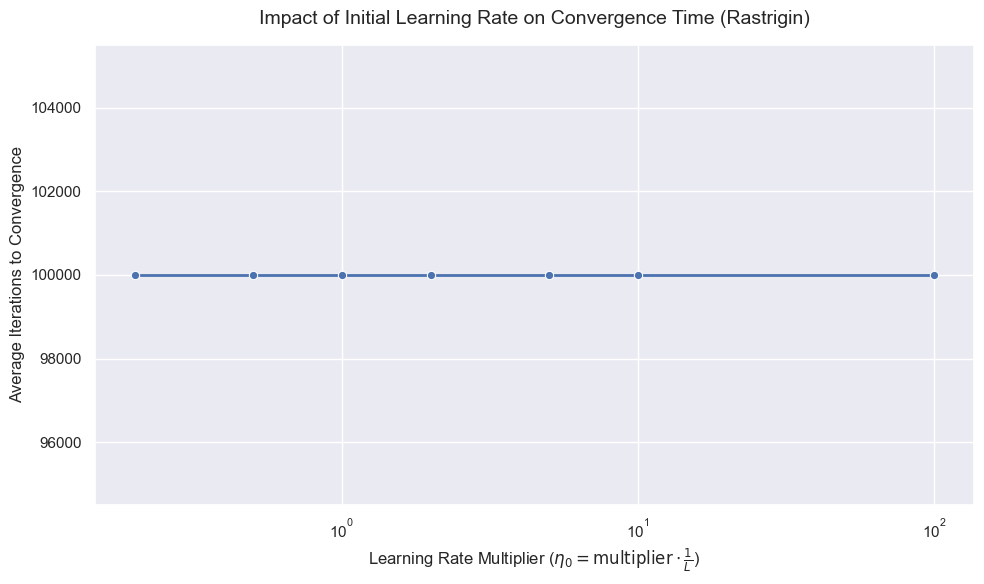

In [6]:
df = pd.read_csv("eta_convergence_rastrigin_results.csv")

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=df, 
    x="eta_multiplier", 
    y="avg_iters", 
    marker="o", 
    errorbar='sd',
    linewidth=2
)

ax.set_xscale("log")

plt.title("Impact of Initial Learning Rate on Convergence Time (Rastrigin)", fontsize=14, pad=15)
plt.xlabel("Learning Rate Multiplier ($\\eta_0 = \mathrm{multiplier} \cdot \\frac{1}{L}$)", fontsize=12)
plt.ylabel("Average Iterations to Convergence", fontsize=12)

plt.tight_layout()
plt.show()